# Radio Telemetry Tracker DSP4 Package

Before we can start, we need a way to generate SDR data.

In this model, the trasmitter emits an on-off-keyed (pulsed) cosine signal at frequency f (with carrier drift possible later), with pulse width D and period T (and an unknown offset tao). We also multiple by an amplitude factor gamma (which may depend on the gemoetry between the tag and observer) and add additive white Gaussian noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Define helper functions to simulate the pulsed (on–off–keyed) signal

In [2]:
def rect_func(t, D, T, tau):
    """
    Periodic rectangular function:
    Returns 1 if (t-tau) mod T is less than D, else 0.
    """
    return ((t - tau) % T) < D


def simulate_transmitter_signal(t, f, D, T_period, tau, gamma, phi=0.0):
    """
    Simulate the IQ signal for a single transmitter.
    """
    envelope = np.array([1.0 if rect_func(ti, D, T_period, tau) else 0.0 for ti in t])
    carrier = np.exp(1j * (2 * np.pi * f * t + phi))
    return gamma * carrier * envelope


def simulate_multiple_transmitters(fs, T_total, transmitter_params, noise_std=0.2):
    """
    Simulate IQ data for multiple transmitters and add noise.
    """
    t = np.arange(0, T_total, 1 / fs)
    signal = np.zeros_like(t, dtype=complex)
    for params in transmitter_params:
        f = params["f"]
        D = params["D"]
        T_period = params["T"]
        tau = params["tau"]
        gamma = params["gamma"]
        phi = params.get("phi", 0.0)
        sig = simulate_transmitter_signal(t, f, D, T_period, tau, gamma, phi)
        signal += sig
    # Add complex Gaussian noise
    noise = (np.random.randn(len(t)) + 1j * np.random.randn(len(t))) * (
        noise_std / np.sqrt(2)
    )
    return t, signal + noise

### Simulate data from multiple transmitters

In [6]:
fs = 10000  # Sampling rate: 10 kHz
T_total = 2.0  # Duration: 2 seconds

# Define three transmitters with higher frequencies.
transmitter_params = [
    {"f": 4000, "D": 0.05, "T": 0.5, "tau": 0.1, "gamma": 1.0, "phi": 0.0},
    {"f": 3000, "D": 0.04, "T": 0.4, "tau": 0.2, "gamma": 0.8, "phi": np.pi / 4},
    {"f": 1000, "D": 0.06, "T": 0.6, "tau": 0.15, "gamma": 0.5, "phi": np.pi / 2},
]

# Simulate the IQ data from multiple transmitters.
t, sdr_data = simulate_multiple_transmitters(
    fs, T_total, transmitter_params, noise_std=0.2
)

### Plot time-domain IQ data: Real, Imaginary, and Envelope

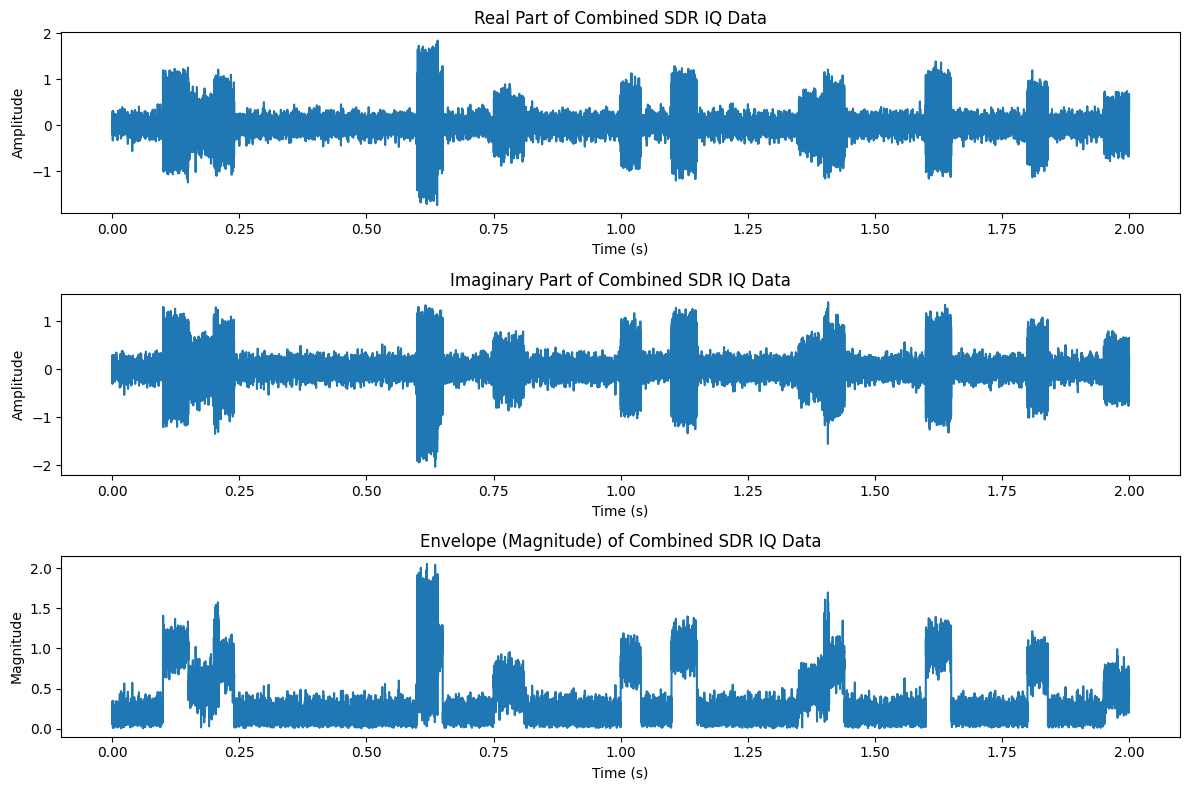

In [7]:
# Plot time-domain IQ data
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t, np.real(sdr_data))
plt.title("Real Part of Combined SDR IQ Data")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 2)
plt.plot(t, np.imag(sdr_data))
plt.title("Imaginary Part of Combined SDR IQ Data")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 3)
plt.plot(t, np.abs(sdr_data))
plt.title("Envelope (Magnitude) of Combined SDR IQ Data")
plt.xlabel("Time (s)")
plt.ylabel("Magnitude")
plt.tight_layout()
plt.show()

### Compute and plot a waterfall (spectrogram) of the combined signal

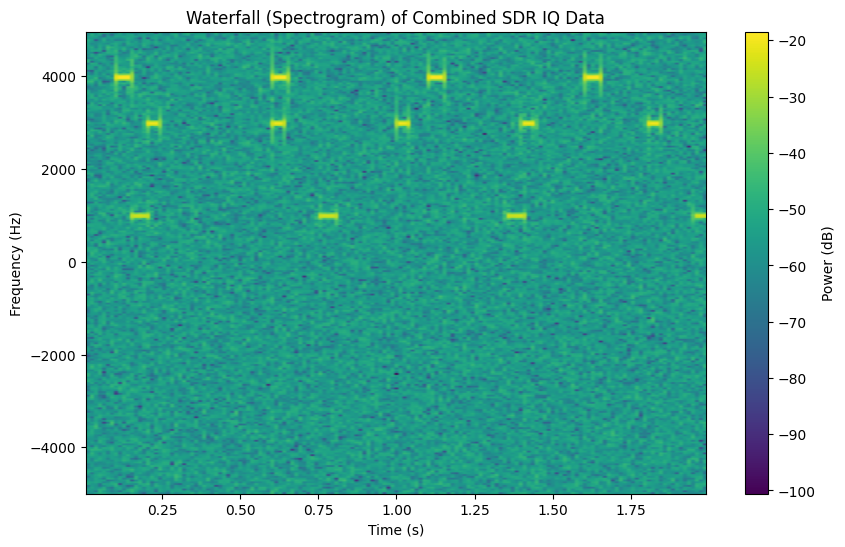

In [8]:
# Plot a waterfall (spectrogram) using specgram
plt.figure(figsize=(10, 6))
# Using specgram directly. You can adjust NFFT and noverlap as needed.
Pxx, freqs, bins, im = plt.specgram(sdr_data, NFFT=256, Fs=fs, noverlap=128, cmap='viridis')
plt.title("Waterfall (Spectrogram) of Combined SDR IQ Data")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
cbar = plt.colorbar()
cbar.set_label("Power (dB)")
plt.show()